# MSDM 5002 HW5

Author：    LAN Tianwei 藍天蔚<br>
ID：        21230969<br>
Email：     tlanaa@connect.ust.hk<br>

# Q1 - GMB

In [13]:
import pandas as pd
from requests import get

BASE = "https://data.etagmb.gov.hk"
TARGET_REGION = "NT"
KEYWORDS = [
    "hong kong university of science and technology",
    "hkust",
    "香港科技大學",
    "香港科技大学",
]

## (a) List all the GMBs pass UST North and South

If you want to find `route_id` of a certain route, do it like this (but can't guarantee unique id):

In [113]:
route_name = '11B'
print(get(f"{BASE}/route/NT/{route_name}", timeout=10).json()['data'][0]['route_id'])
print(get(f"{BASE}/route/NT/{route_name}", timeout=10).json()['data'][1]['route_id'])

2004827
2004828


In [43]:
route_codes = get(f"{BASE}/route/{TARGET_REGION}").json()["data"]["routes"]

def stop_mentions_ust(stop):
    text = " ".join(
        filter(
            None,
            [stop.get("name_en", ""), stop.get("name_tc", ""), stop.get("name_sc", "")],
        )
    ).lower()
    return any(keyword in text for keyword in KEYWORDS)

def get_route_ids(region = TARGET_REGION):
    matches = []
    for route_code in route_codes:
        variants = get(f"{BASE}/route/{region}/{route_code}").json()["data"]
        for variant in variants:
            route_id = variant["route_id"]
            for direction in variant["directions"]:
                route_seq = direction["route_seq"]
                stops = get(f"{BASE}/route-stop/{route_id}/{route_seq}").json()["data"]["route_stops"]
                for stop in stops:
                    if stop_mentions_ust(stop):
                        matches.append(
                            {
                                "route_code"    : variant["route_code"],
                                "route_id"      : route_id,
                                "route_seq"     : route_seq,
                                "stop_seq"      : stop["stop_seq"],
                                "stop_id"       : stop["stop_id"],
                                "stop_name_tc"  : stop["name_tc"],
                                "dest_tc"       : direction["dest_tc"]
                            }
                        )
                        continue
    return pd.DataFrame(matches)

route_stop_id_map = get_route_ids()
route_stop_id_map

,route_code,route_id,route_seq,stop_seq,stop_id,stop_name_tc,dest_tc
0,101M,2003240,1,5,20005018,"清水灣道, 近香港科技大學",西貢
1,104,2007200,1,1,20015226,香港科技大學(南站),觀塘(循環線)
2,104,2007200,1,24,20015226,香港科技大學(南站),觀塘(循環線)
3,11,2004791,1,7,20013010,香港科技大學(南站),彩虹站(龍翔道)
4,11,2004791,2,10,20012472,香港科技大學(北站),坑口村
5,11B,2004827,1,1,20012474,香港科技大學(北站),彩虹站(龍翔道)
6,11B,2004827,2,10,20012474,香港科技大學(北站),香港科技大學(北站)
7,11B,2004828,1,1,20013011,香港科技大學(南站),彩虹站(龍翔道)
8,11M,2004825,1,3,20012474,香港科技大學(北站),香港科技大學(北站)
9,11M,2004825,2,1,20012474,香港科技大學(北站),坑口站公共運輸交匯處


In [44]:
route_id_map = route_stop_id_map[["route_code", "route_id"]].drop_duplicates().sort_values("route_code").reset_index(drop=True)
route_id_map

,route_code,route_id
0,101M,2003240
1,104,2007200
2,11,2004791
3,11B,2004827
4,11B,2004828
5,11M,2004825
6,11S,2004826
7,12,2004764


## (b)`stop_id`s of UST North and South

In [47]:
stop_id_map = route_stop_id_map[["stop_name_tc","stop_id"]].drop_duplicates().sort_values("stop_id").reset_index(drop=True)
ust_n_id = stop_id_map[stop_id_map["stop_name_tc"]== "香港科技大學(北站)"]
ust_s_id = stop_id_map[stop_id_map["stop_name_tc"]== "香港科技大學(南站)"]

print("stop_id of UST North:\n", ust_n_id,"\n")
print("stop_id of UST South:\n", ust_s_id,"\n")

stop_id of UST North:
   stop_name_tc   stop_id
1   香港科技大學(北站)  20012472
2   香港科技大學(北站)  20012474 

stop_id of UST South:
   stop_name_tc   stop_id
4   香港科技大學(南站)  20013010
5   香港科技大學(南站)  20013011
6   香港科技大學(南站)  20015226 



## (c) get timetable

In [60]:
from datetime import datetime, timedelta

def _get_eta_df(route_code, route_id, stop_id):
    eta_resp = get(f"{BASE}/eta/route-stop/{route_id}/{stop_id}", timeout=10).json()
    if eta_resp == {'code': 404, 'message': 'ETA not Found'}:   # situation for getting nothing, return empty dataframe
        return pd.DataFrame(columns=["ETA", "route_code"])
    
    rows = []
    now = datetime.now().astimezone()

    for occ in eta_resp["data"]:
        if not occ["enabled"]:
            continue
        for e in occ["eta"]:
            eta_time = (now + timedelta(minutes=e["diff"])).strftime("%H:%M")
            rows.append({"ETA": eta_time, "route_code": route_code})

    return pd.DataFrame(rows)

def get_timetable(direction):
    direction = direction.upper()
    if direction == "N":
        total_map = route_stop_id_map[route_stop_id_map["stop_name_tc"]=="香港科技大學(北站)"]
    elif direction == "S":
        total_map = route_stop_id_map[route_stop_id_map["stop_name_tc"]=="香港科技大學(南站)"]
    else:
        return "Please Enter 'N' or 'S'"

    tables = []
    for index, row in total_map.iterrows():
        rid = row["route_id"]
        code = row["route_code"]
        sid = row["stop_id"]
        dest = row["dest_tc"]
        eta_df = _get_eta_df(code,rid,sid)
        if eta_df.empty:
            continue
        eta_df["dest_tc"] = dest
        tables.append(eta_df[["route_code", "dest_tc", "ETA"]])

    if not tables:
        return pd.DataFrame(columns=["route_code", "dest_tc", "ETA"])

    df = pd.concat(tables, ignore_index=True).sort_values("ETA").reset_index(drop=True)
    df = df[~df["dest_tc"].str.contains("香港科技大學", case=False, na=False)].drop_duplicates().reset_index(drop=True)
    return df

In [63]:
get_timetable("N")

,route_code,dest_tc,ETA
0,11M,坑口站公共運輸交匯處,20:41
1,11M,坑口站公共運輸交匯處,20:46
2,11M,坑口站公共運輸交匯處,20:47
3,11,坑口村,20:53
4,11M,坑口站公共運輸交匯處,20:55
5,11,坑口村,20:59
6,11M,坑口站公共運輸交匯處,21:03
7,11,坑口村,21:04


In [64]:
get_timetable("S")

,route_code,dest_tc,ETA
0,11,彩虹站(龍翔道),20:45
1,104,觀塘(循環線),20:50
2,11,彩虹站(龍翔道),20:50
3,11,彩虹站(龍翔道),20:54
4,104,觀塘(循環線),21:02
5,104,觀塘(循環線),21:35


# Q2 - HKO

## (a) Download Table

In [8]:
import requests
import json
import pandas as pd
from datetime import datetime

# Required columns
WEATHER_COLS = [
    ("Mean Pressure (hPa)", 1),
    ("Absolute Daily Max Air Temp. (°C)", 2),
    ("Mean Air Temp. (°C)", 3),
    ("Absolute Daily Min Air Temp. (°C)", 4),
    ("Mean Dew Point (°C)", 5),
    ("Mean Relative Humidity (%)", 6),
    ("Mean Amount of Cloud (%)", 7),
    ("Total Rainfall (mm)", 8),
    ("Total Bright Sunshine (hours)", 9),
]

START_DATE = pd.Timestamp(datetime(2000, 11, 1))
END_DATE = pd.Timestamp(datetime(2025, 10, 31))

def download_yearly_extract(year):
    """Download yearly data from HKO XML API"""
    url = f"https://www.hko.gov.hk/cis/dailyExtract/dailyExtract_{year}.xml"
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    return json.loads(response.text)["stn"]["data"]

def clean_value(raw, column_name):
    """Clean and convert data values"""
    if raw is None:
        return None
    text = str(raw).replace(" ", "").replace("*", "").replace("#", "").strip()
    if not text or text in {"-", "NA"}:
        return None
    if column_name == "Total Rainfall (mm)" and text.lower().startswith("trace"):
        return 0.02
    try:
        return float(text)
    except ValueError:
        return None

def scrape_hko_data():
    """Scrape HKO weather data from Nov 2000 to Oct 2025"""
    records = []
    
    for year in range(2000, 2026):
        # print(f"Downloading year {year}...")
        year_data = download_yearly_extract(year)
        
        for month_block in year_data:
            month = int(month_block["month"])
            
            for row in month_block["dayData"]:
                day_label = str(row[0])
                if not day_label.isdigit():
                    continue  # skip "Mean/Total" and "Normal" rows
                
                date = pd.Timestamp(datetime(year, month, int(day_label)))
                if not (START_DATE <= date <= END_DATE):
                    continue
                
                entry = {"Date": date}
                for col_name, idx in WEATHER_COLS:
                    entry[col_name] = clean_value(row[idx], col_name)
                records.append(entry)
    
    df = pd.DataFrame(records).sort_values("Date").reset_index(drop=True)
    return df

# Execute scraping
weather_df = scrape_hko_data()

# Save to CSV
weather_df.to_csv("hko_daily_weather_2000_2025.csv", index=False)

# Display results
expected_days = (END_DATE - START_DATE).days + 1
print(f"\nCollected {len(weather_df)} rows between {weather_df['Date'].min().date()} and {weather_df['Date'].max().date()}")
print(f"Expected: {expected_days} days")
# print(f"\nFirst few rows:")
# print(weather_df.head())



Collected 9131 rows between 2000-11-01 and 2025-10-31
Expected: 9131 days


## (b) Scrape warning database

In [ ]:
from datetime import datetime, timedelta

WARNING_SPECS = {
    "very_hot": {
        "url": "https://www.hko.gov.hk/dps/wxinfo/climat/warndb/hot.dat",
        "has_color": False,
    },
    "cold": {
        "url": "https://www.hko.gov.hk/dps/wxinfo/climat/warndb/cold.dat",
        "has_color": False,
    },
    "fire": {
        "url": "https://www.hko.gov.hk/dps/wxinfo/climat/warndb/fire.dat",
        "has_color": True,
    },
    "rainstorm": {
        "url": "https://www.hko.gov.hk/dps/wxinfo/climat/warndb/rstorm.dat",
        "has_color": True,
    },
}

START_DATE = pd.Timestamp(datetime(2000, 11, 1))
END_DATE = pd.Timestamp(datetime(2025, 10, 31))

def parse_warning_lines(text, has_color):
    rows = []
    for line in text.strip().splitlines():
        parts = [item for item in line.strip().split("\t") if item.strip()]
        if not parts:
            continue
        
        colour = parts[0] if has_color else None
        offset = 1 if has_color else 0
        
        try:
            numbers = list(map(int, parts[offset : offset + 10]))
        except ValueError:
            continue
        
        if len(numbers) < 10:
            continue
        
        try:
            start = datetime(numbers[0], numbers[1], numbers[2]) + timedelta(hours=numbers[3], minutes=numbers[4])
            end = datetime(numbers[5], numbers[6], numbers[7]) + timedelta(hours=numbers[8], minutes=numbers[9])
        except Exception:
            continue
        
        rows.append({"Start": start, "End": end, "Colour": colour})
    
    return rows

def load_warning_table(name, spec):
    # print(f"Downloading {name} warning data...")
    
    response = requests.get(spec["url"], timeout=60)
    response.raise_for_status()
    
    events = parse_warning_lines(response.text, spec["has_color"])
    df = pd.DataFrame(events)
    
    df = df[(df["End"] >= START_DATE) & (df["Start"] <= END_DATE)].sort_values("Start").reset_index(drop=True)
    
    csv_path = f"warning_{name}.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved to {csv_path}")
    
    return df

warning_tables = {name: load_warning_table(name, spec) for name, spec in WARNING_SPECS.items()}

# print("\nData Preview:")
# for key, df in warning_tables.items():
#     print(f"\n{key.upper()} ({len(df)} records):")
#     print(df.head(3))


Saved to warning_very_hot.csv
Saved to warning_cold.csv
Saved to warning_fire.csv
Saved to warning_rainstorm.csv


## (c) Flag by signals

In [14]:
import pandas as pd

# Load all data files
weather_df = pd.read_csv("hko_daily_weather_2000_2025.csv", parse_dates=["Date"])
very_hot_df = pd.read_csv("warning_very_hot.csv", parse_dates=["Start", "End"])
cold_df = pd.read_csv("warning_cold.csv", parse_dates=["Start", "End"])
fire_df = pd.read_csv("warning_fire.csv", parse_dates=["Start", "End"])
rainstorm_df = pd.read_csv("warning_rainstorm.csv", parse_dates=["Start", "End"])

# Initialize new columns
weather_df["Very Hot Weather Warning"] = False
weather_df["Cold Weather Warning"] = False
weather_df["Fire Danger Warning"] = 0
weather_df["Rainstorm Warning"] = 0

# Process Very Hot Weather Warning (True/False)
for _, row in very_hot_df.iterrows():
    start_date = row["Start"].floor('D')
    end_date = row["End"].floor('D')
    affected_dates = pd.date_range(start=start_date, end=end_date)
    weather_df.loc[weather_df["Date"].isin(affected_dates), "Very Hot Weather Warning"] = True

# Process Cold Weather Warning (True/False)
for _, row in cold_df.iterrows():
    start_date = row["Start"].floor('D')
    end_date = row["End"].floor('D')
    affected_dates = pd.date_range(start=start_date, end=end_date)
    weather_df.loc[weather_df["Date"].isin(affected_dates), "Cold Weather Warning"] = True

# Process Fire Danger Warning (0=None, 1=Yellow, 2=Red)
fire_color_map = {"Y": 1, "R": 2}
temp_fire_series = pd.Series(0, index=weather_df.index)

for _, row in fire_df.iterrows():
    start_date = row["Start"].floor('D')
    end_date = row["End"].floor('D')
    affected_dates = pd.date_range(start=start_date, end=end_date)
    
    val = fire_color_map.get(row["Colour"], 0)
    mask = weather_df["Date"].isin(affected_dates)
    
    # Update with max value to keep highest signal for the day
    current_vals = temp_fire_series[mask]
    new_vals = pd.Series(val, index=current_vals.index)
    temp_fire_series[mask] = current_vals.combine(new_vals, max)

weather_df["Fire Danger Warning"] = temp_fire_series

# Process Rainstorm Warning (0=None, 1=Amber, 2=Red, 3=Black)
rain_color_map = {"A": 1, "R": 2, "B": 3}
temp_rain_series = pd.Series(0, index=weather_df.index)

for _, row in rainstorm_df.iterrows():
    start_date = row["Start"].floor('D')
    end_date = row["End"].floor('D')
    affected_dates = pd.date_range(start=start_date, end=end_date)
    
    val = rain_color_map.get(row["Colour"], 0)
    mask = weather_df["Date"].isin(affected_dates)
    
    # Update with max value
    current_vals = temp_rain_series[mask]
    new_vals = pd.Series(val, index=current_vals.index)
    temp_rain_series[mask] = current_vals.combine(new_vals, max)

weather_df["Rainstorm Warning"] = temp_rain_series

# Save result
output_file = "hko_weather_with_warnings.csv"
weather_df.to_csv(output_file, index=False)

print(f"File saved as {output_file}")
# print("\nData Preview:")
# print(weather_df.head())


File saved as hko_weather_with_warnings.csv


## (d) weather histograms

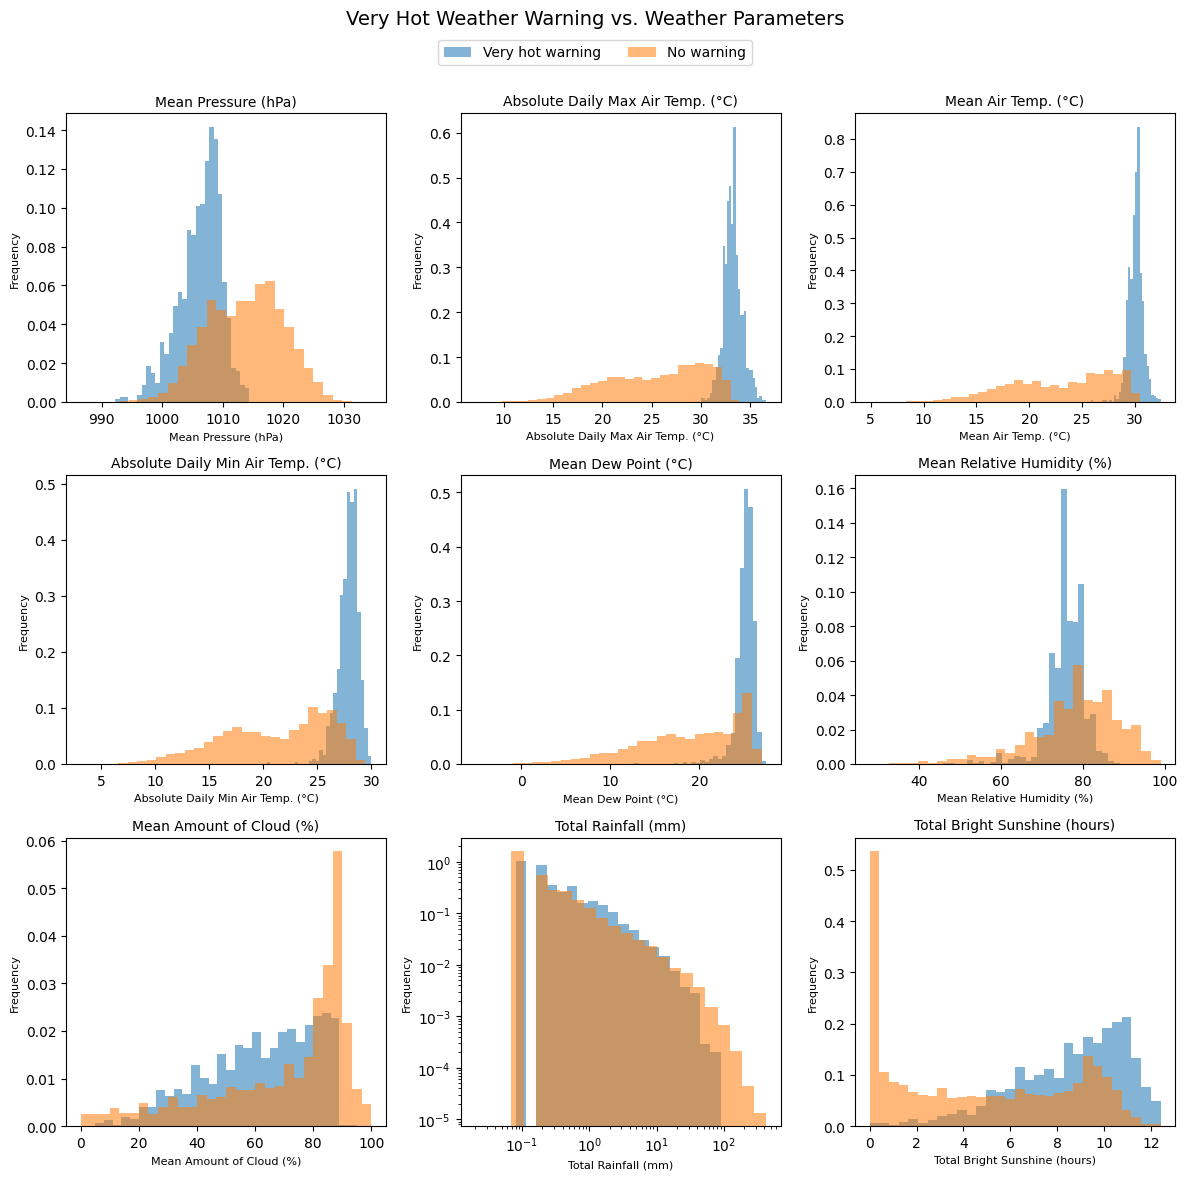

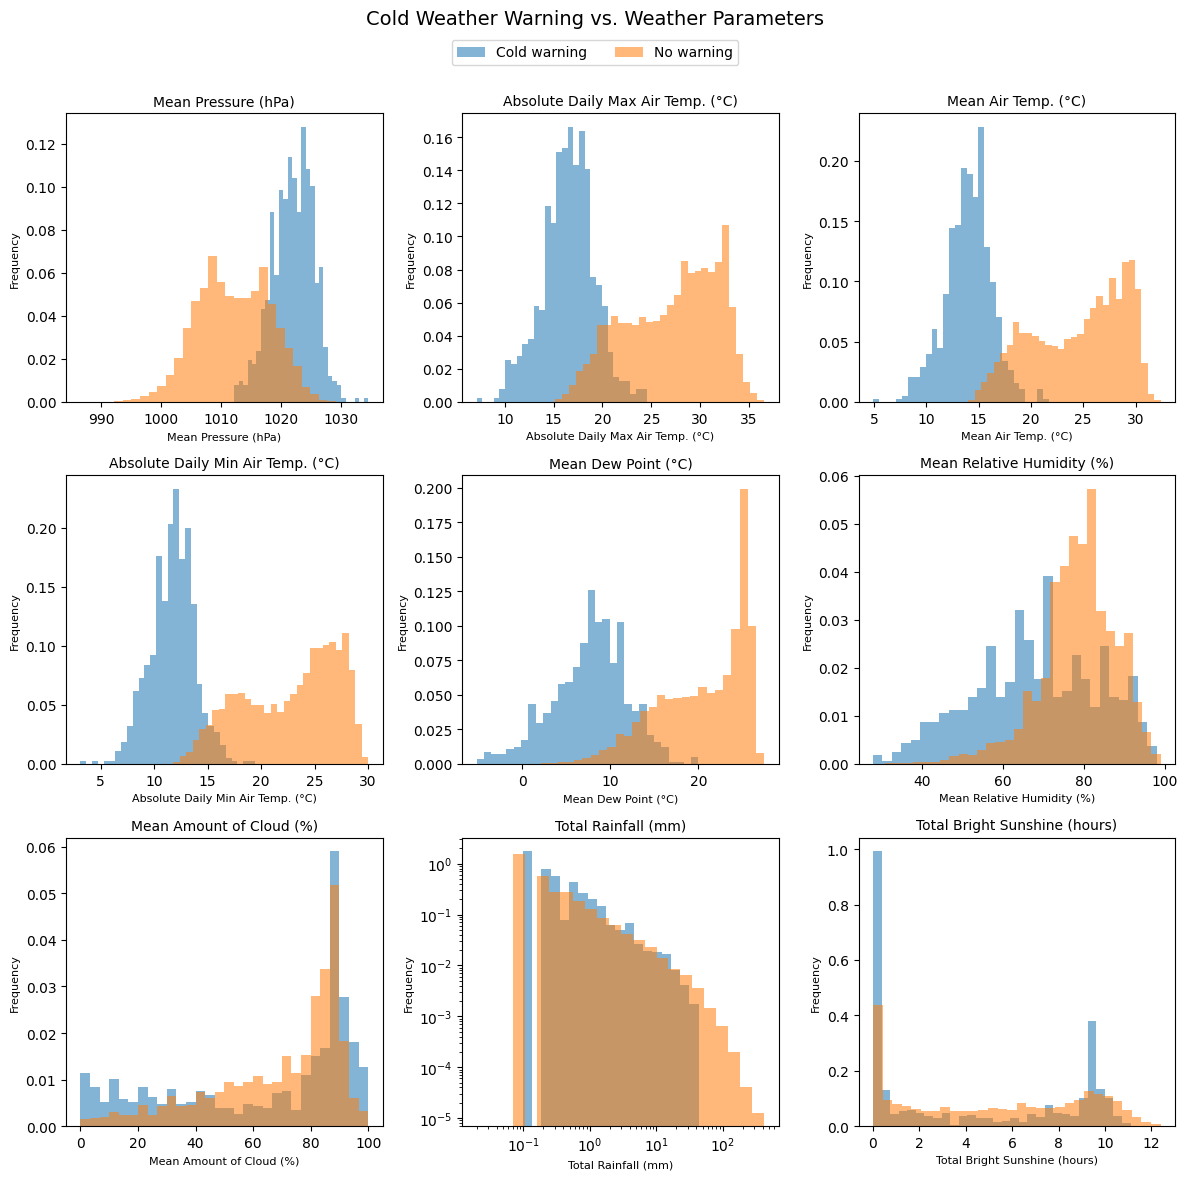

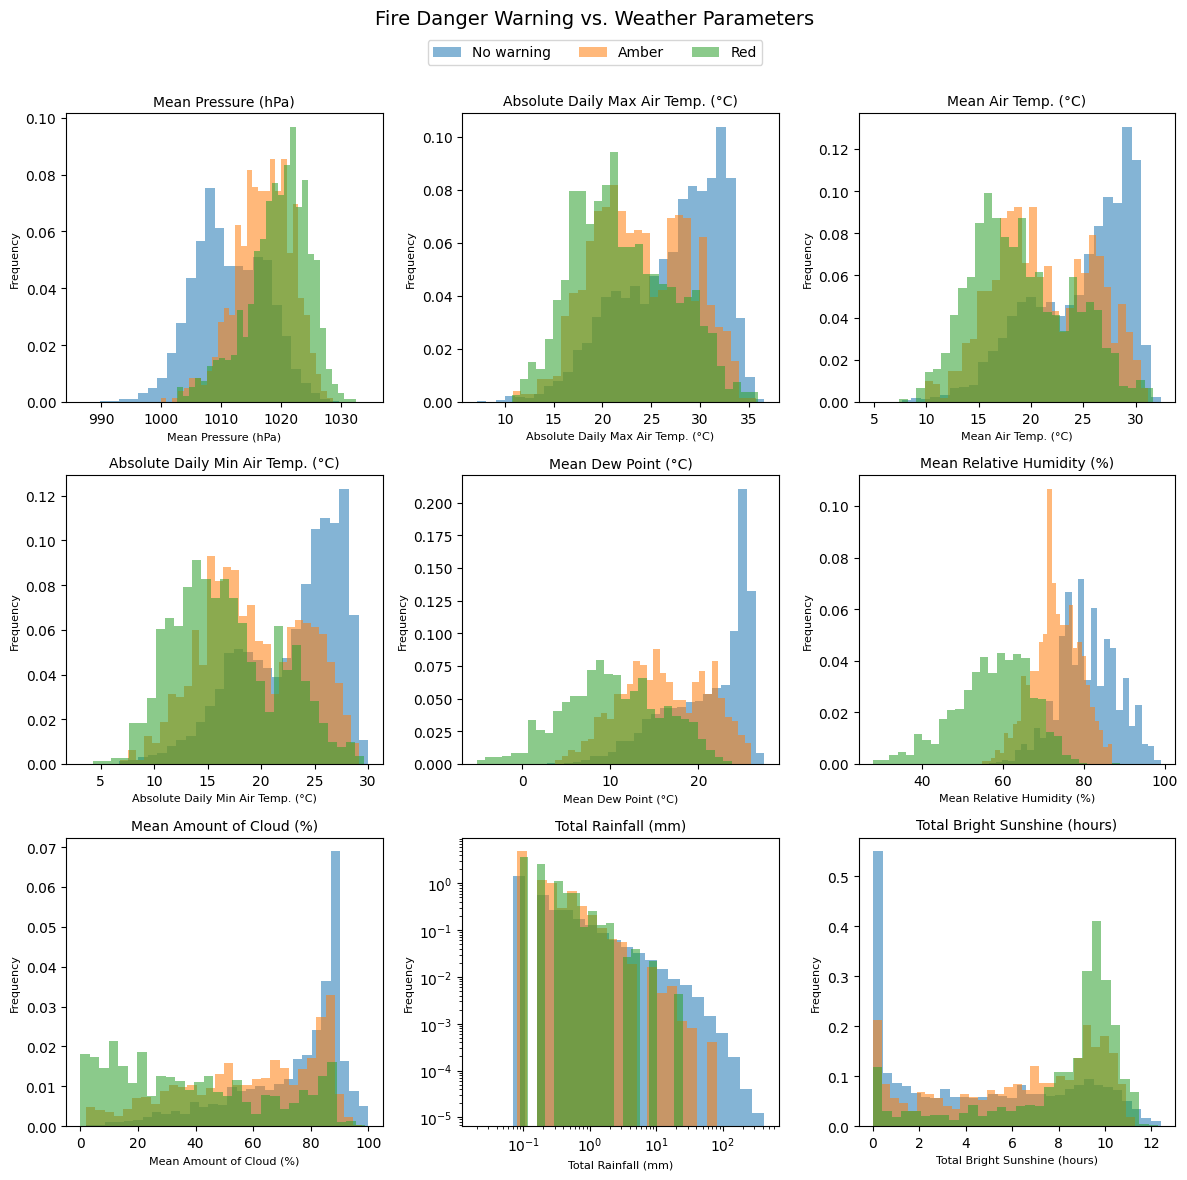

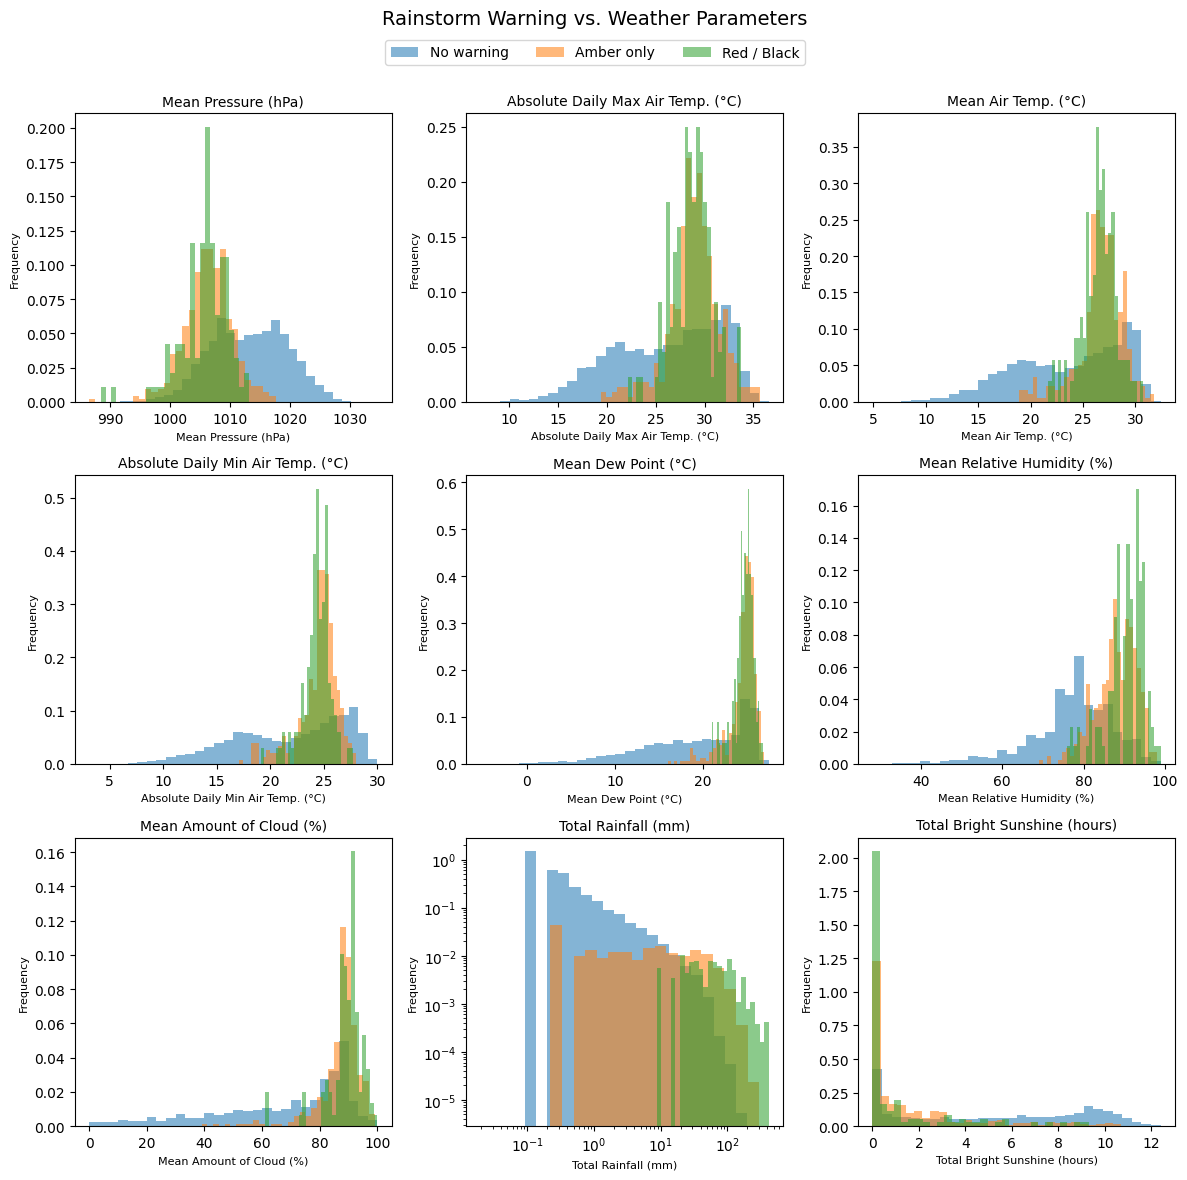

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 1. Reload the merged data (assuming previous part ran successfully)
# Make sure 'hko_weather_with_warnings.csv' is in the current directory
weather_daily = pd.read_csv("hko_weather_with_warnings.csv")

# 2. Define the 9 metrics to plot
METRIC_NAMES = [
    "Mean Pressure (hPa)",
    "Absolute Daily Max Air Temp. (°C)",
    "Mean Air Temp. (°C)",
    "Absolute Daily Min Air Temp. (°C)",
    "Mean Dew Point (°C)",
    "Mean Relative Humidity (%)",
    "Mean Amount of Cloud (%)",
    "Total Rainfall (mm)",
    "Total Bright Sunshine (hours)"
]

# Output directory (current directory)
FIG_DIR = Path(".")

# 3. Plotting function
def plot_warning_histograms(df: pd.DataFrame, groups: list, title: str, outfile: Path):
    """
    Generates a 3x3 grid of histograms for the specified warning groups.
    """
    # Setup 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.ravel()
    
    for idx, metric in enumerate(METRIC_NAMES):
        ax = axes[idx]
        
        # Plot histogram for each group (e.g. Warning vs No Warning)
        for label, mask in groups:
            series = df.loc[mask, metric].dropna()
            
            # Special handling for Total Rainfall: log-log plot
            if metric == "Total Rainfall (mm)":
                # Filter > 0 for log scale
                series_log = series[series > 0]
                if series_log.empty:
                    continue
                
                try:
                    # Create log-spaced bins
                    bins = np.logspace(np.log10(series_log.min()), np.log10(series_log.max()), 25)
                    ax.hist(series_log, bins=bins, density=True, alpha=0.55, label=label)
                    ax.set_xscale("log")
                    ax.set_yscale("log")
                except:
                    pass
            else:
                # Normal histogram for other metrics
                ax.hist(series, bins=30, density=True, alpha=0.55, label=label)
        
        ax.set_title(metric, fontsize=10)
        ax.set_xlabel(metric, fontsize=8)
        ax.set_ylabel("Frequency", fontsize=8)

    # Add single legend at the top
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=len(groups), bbox_to_anchor=(0.5, 0.96))
    
    fig.suptitle(title, y=0.98, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95]) # Leave space for title/legend
    
    # Save figure
    fig.savefig(outfile, dpi=200)
    plt.show(fig)
    # print(f"Saved plot to {outfile}")

# 4. Define Groups for each warning

def mask_series(condition):
    return condition.fillna(False)

# Very Hot Warning Groups
very_hot_groups = [
    ("Very hot warning", mask_series(weather_daily["Very Hot Weather Warning"] == True)),
    ("No warning", mask_series(weather_daily["Very Hot Weather Warning"] == False)),
]

# Cold Weather Warning Groups
cold_groups = [
    ("Cold warning", mask_series(weather_daily["Cold Weather Warning"] == True)),
    ("No warning", mask_series(weather_daily["Cold Weather Warning"] == False)),
]

# Fire Danger Warning Groups
fire_groups = [
    ("No warning", mask_series(weather_daily["Fire Danger Warning"] == 0)),
    ("Amber", mask_series(weather_daily["Fire Danger Warning"] == 1)),
    ("Red", mask_series(weather_daily["Fire Danger Warning"] == 2)),
]

# Rainstorm Warning Groups
rain_groups = [
    ("No warning", mask_series(weather_daily["Rainstorm Warning"] == 0)),
    ("Amber only", mask_series(weather_daily["Rainstorm Warning"] == 1)),
    ("Red / Black", mask_series(weather_daily["Rainstorm Warning"] >= 2)),
]

# 5. Generate all plots
plot_warning_histograms(
    weather_daily,
    very_hot_groups,
    title="Very Hot Weather Warning vs. Weather Parameters",
    outfile=FIG_DIR / "hist_very_hot.png",
)

plot_warning_histograms(
    weather_daily,
    cold_groups,
    title="Cold Weather Warning vs. Weather Parameters",
    outfile=FIG_DIR / "hist_cold.png",
)

plot_warning_histograms(
    weather_daily,
    fire_groups,
    title="Fire Danger Warning vs. Weather Parameters",
    outfile=FIG_DIR / "hist_fire.png",
)

plot_warning_histograms(
    weather_daily,
    rain_groups,
    title="Rainstorm Warning vs. Weather Parameters",
    outfile=FIG_DIR / "hist_rainstorm.png",
)
